#  Использование предобученных моделей для классификации изображений

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы:
* Deep Learning with PyTorch (2020) Авторы: Eli Stevens, Luca Antiga, Thomas Viehmann
* https://pytorch.org/vision/0.16/transforms.html#v2-api-reference-recommended
* https://pytorch.org/vision/main/generated/torchvision.datasets.ImageFolder.html
* https://pytorch.org/vision/stable/models.html
* https://albumentations.ai/docs/getting_started/image_augmentation/

In [1]:
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
import torchvision
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import accuracy_score
import seaborn as sns
import numpy as np
import zipfile
import random
from torchvision import models

## Задачи для совместного разбора

1\. Загрузите предобученную модель из `torchvision`. Познакомьтесь с ее архитектурой. Заморозьте веса нескольких слоев.

## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Используя реализацию из `torchvision`, cоздайте модель `vgg16` и загрузите предобученные веса `IMAGENET1K_V1`. Выведите на экран структуру модели, количество слоев и количество настраиваемых (`requires_grad==True`) параметров модели.

- [ ] Проверено на семинаре

In [2]:
model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

print("Структура модели VGG16:")
print(model)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:02<00:00, 234MB/s]


Структура модели VGG16:
VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=

In [3]:
total_layers = len(list(model.parameters()))
print("\nКоличество слоев:", total_layers)


Количество слоев: 32


In [4]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Количество настраиваемых параметров:", trainable_params)

Количество настраиваемых параметров: 138357544


<p class="task" id="2"></p>

2\. Создайте датасет `CatBreeds` на основе данных из архива `cat_breeds_4.zip`. Разбейте датасет на обучающее и тестовое множество в соотношении 80 на 20%.

К обучающему датасету примените следующее преобразование: приведите картинки к размеру 256x256, затем обрежьте по центру с размером 224х224, затем переведите изображения в тензор и нормализуйте значения интенсивности пикселей (`mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)`).

К тестовому датасету примените преобразование `VGG16_Weights.IMAGENET1K_V1.transforms`.

- [ ] Проверено на семинаре

In [6]:
zip_path = 'cat_breeds_4.zip'
extract_path = '/content'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [7]:
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
])

test_transform = models.VGG16_Weights.IMAGENET1K_V1.transforms()

dataset = datasets.ImageFolder(root='/content/cat_breeds_4', transform=train_transform)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

test_dataset.dataset.transform = test_transform

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

<p class="task" id="3"></p>

3\. Заморозьте все веса модели из предыдущего задания. Замените последний слой `Linear` классификатора на новый слой, соответствующий задаче. После изменения последнего слоя выведите на экран количество настраиваемых (`requires_grad==True`) параметров модели. Решите задачу, используя модель с замороженными весами и изменнным последним слоем.

Постройте график изменения значения функции потерь на обучающем множестве в зависимости от номера эпохи, графики изменения метрики accuracy на обучающем и тестовом множестве в зависимости от эпохи. Выведите на экран итоговое значение метрики accuracy на обучающем и тестовом множестве.

- [ ] Проверено на семинаре

In [8]:
dataset.classes.__len__(), dataset[0][0].shape

(4, torch.Size([3, 224, 224]))

In [9]:
for param in model.parameters():
    param.requires_grad = False

model.classifier[6] = nn.Linear(in_features=4096, out_features=4)

print("Количество настраиваемых параметров:", sum(p.numel() for p in model.parameters() if p.requires_grad))

Количество настраиваемых параметров: 16388


In [10]:
model = model.cpu()

crit = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier[6].parameters(), lr=0.001)

train_losses = []
train_accuracies = []
test_accuracies = []

In [11]:
for epoch in range(10):
    model.train()
    epoch_loss = 0.0
    correct_train = 0
    total_train = 0
    for images, labels in train_loader:
        images, labels = images.cpu(), labels.cpu()

        optimizer.zero_grad()

        outputs = model(images)
        loss = crit(outputs, labels)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct_train += (predicted == labels).sum().item()
        total_train += labels.size(0)

    train_loss = epoch_loss / len(train_loader.dataset)
    train_accuracy = correct_train / total_train
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    model.eval()
    correct_test = 0
    total_test = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.cpu(), labels.cpu()
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            correct_test += (predicted == labels).sum().item()
            total_test += labels.size(0)

    test_accuracy = correct_test / total_test
    test_accuracies.append(test_accuracy)

    print(f"Эпоха {epoch+1}, Потери: {train_loss:.4f}, "
          f"Точность на обучающем: {train_accuracy:.4f}, "
          f"Точность на тестовом: {test_accuracy:.4f}")

Эпоха 1, Потери: 0.8181, Точность на обучающем: 0.6609, Точность на тестовом: 0.7625
Эпоха 2, Потери: 0.5812, Точность на обучающем: 0.7638, Точность на тестовом: 0.7863
Эпоха 3, Потери: 0.5340, Точность на обучающем: 0.7856, Точность на тестовом: 0.7963
Эпоха 4, Потери: 0.4955, Точность на обучающем: 0.7950, Точность на тестовом: 0.7987
Эпоха 5, Потери: 0.4795, Точность на обучающем: 0.8103, Точность на тестовом: 0.7937
Эпоха 6, Потери: 0.4656, Точность на обучающем: 0.8137, Точность на тестовом: 0.7950
Эпоха 7, Потери: 0.4582, Точность на обучающем: 0.8203, Точность на тестовом: 0.7975
Эпоха 8, Потери: 0.4371, Точность на обучающем: 0.8294, Точность на тестовом: 0.7937
Эпоха 9, Потери: 0.4341, Точность на обучающем: 0.8337, Точность на тестовом: 0.7975
Эпоха 10, Потери: 0.4285, Точность на обучающем: 0.8325, Точность на тестовом: 0.7987


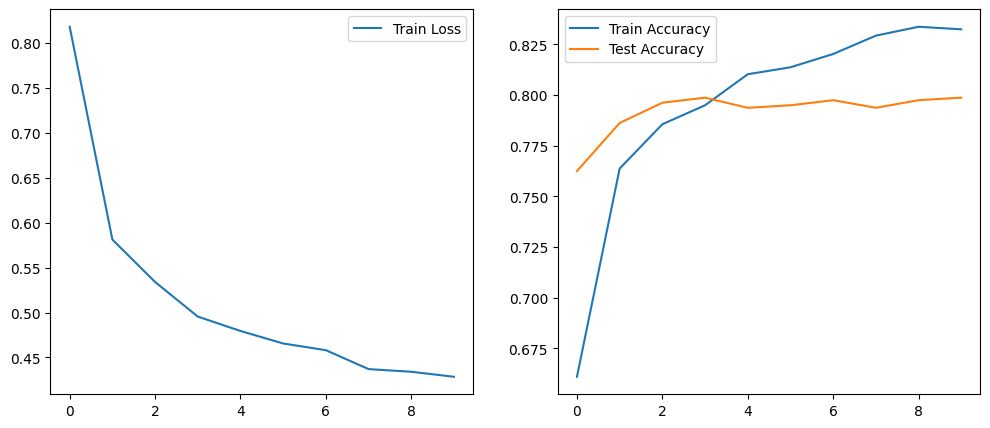

In [12]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(test_accuracies, label='Test Accuracy')
plt.legend()

plt.show()

<p class="task" id="4"></p>

4\. Повторите решение предыдущей задачи, заморозив все сверточные слои, кроме последнего (слои классификатора не замораживайте). Сравните качество полученного решения и решения из предыдущей задачи, а также время, затраченное на обучения моделей. Перед началом работы создайте модель заново.

- [ ] Проверено на семинаре

In [13]:
# Заморозка всех сверточных слоев, кроме последнего
for name, param in model.features.named_parameters():
    if '30' not in name:  # '30' соответствует последнему сверточному слою
        param.requires_grad = False

# Обновление выходного слоя классификатора
model.classifier[6] = nn.Linear(in_features=4096, out_features=4)

# Проверка количества настраиваемых параметров
print("Количество настраиваемых параметров:", sum(p.numel() for p in model.parameters() if p.requires_grad))

Количество настраиваемых параметров: 16388


In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [15]:
crit = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

In [17]:
import time

In [19]:
# Обучение и оценка модели
train_losses = []
train_accuracies = []
test_accuracies = []
start_time = time.time()

for epoch in range(10):
    model.train()
    epoch_loss = 0.0
    correct_train = 0
    total_train = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = crit(outputs, labels)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct_train += (predicted == labels).sum().item()
        total_train += labels.size(0)

    train_loss = epoch_loss / len(train_loader.dataset)
    train_accuracy = correct_train / total_train
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    model.eval()
    correct_test = 0
    total_test = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            correct_test += (predicted == labels).sum().item()
            total_test += labels.size(0)

    test_accuracy = correct_test / total_test
    test_accuracies.append(test_accuracy)

    print(f"Эпоха {epoch+1}, Потери: {train_loss:.4f}, "
          f"Точность на обучающем: {train_accuracy:.4f}, "
          f"Точность на тестовом: {test_accuracy:.4f}")

Эпоха 1, Потери: 0.6432, Точность на обучающем: 0.7434, Точность на тестовом: 0.7725
Эпоха 2, Потери: 0.5510, Точность на обучающем: 0.7788, Точность на тестовом: 0.7850
Эпоха 3, Потери: 0.5142, Точность на обучающем: 0.7906, Точность на тестовом: 0.7837
Эпоха 4, Потери: 0.5018, Точность на обучающем: 0.7969, Точность на тестовом: 0.7937
Эпоха 5, Потери: 0.4826, Точность на обучающем: 0.8013, Точность на тестовом: 0.7963
Эпоха 6, Потери: 0.4763, Точность на обучающем: 0.7994, Точность на тестовом: 0.7925
Эпоха 7, Потери: 0.4543, Точность на обучающем: 0.8181, Точность на тестовом: 0.7963
Эпоха 8, Потери: 0.4457, Точность на обучающем: 0.8213, Точность на тестовом: 0.7925
Эпоха 9, Потери: 0.4417, Точность на обучающем: 0.8191, Точность на тестовом: 0.7875
Эпоха 10, Потери: 0.4160, Точность на обучающем: 0.8428, Точность на тестовом: 0.7887


In [20]:
training_time = time.time() - start_time
print(f"Время обучения: {training_time:.2f} секунд")

Время обучения: 1603.97 секунд


<p class="task" id="5"></p>

5\. Повторите решение задачи 3, расширив обучающий набор данных при помощи преобразований из `torchvision`, изменяющих изображение (повороты, изменение интенсивности пикселей, обрезание и т.д.). При оценке модели на тестовой выборке данные преобразования применяться не должны. Решение о том, сколько и каких слоев модели будет обучаться, примите самостоятельно. Перед началом работы создайте модель заново.

- [ ] Проверено на семинаре

## Обратная связь
- [ ] Хочу получить обратную связь по решению

In [22]:
torch.save(model.state_dict(), 'model_04_2.pth')